# Uber Fares 🚙🚙
In this exercise, we'll use Random Forests in order to estimate the price of a Uber ride.

## Importing libraries and dataset
0. Import the usual libraries and read the dataset from this url:
"https://full-stack-bigdata-datasets.s3.eu-west-3.amazonaws.com/Machine+Learning+Supervis%C3%A9/Decision+trees/uber.csv"

In [65]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report,
    mean_absolute_error
)
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings(
    "ignore", category=DeprecationWarning
)  # to avoid deprecation warnings

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

# setting Jedha color palette as default
pio.templates["jedha"] = go.layout.Template(
    layout_colorway=[
        "#4B9AC7",
        "#4BE8E0",
        "#9DD4F3",
        "#97FBF6",
        "#2A7FAF",
        "#23B1AB",
        "#0E3449",
        "#015955",
    ]
)
pio.templates.default = "jedha"
pio.renderers.default = "svg"  # to be replaced by "iframe" if working on JULIE

In [66]:
print("Loading dataset...")
df = pd.read_csv("https://full-stack-bigdata-datasets.s3.eu-west-3.amazonaws.com/Machine+Learning+Supervis%C3%A9/Decision+trees/uber.csv")
print("...Done.")

Loading dataset...
...Done.


## Basic exploring and cleaning
1. Display basic statistics about the dataset. Do you notice some inconsistent values?

In [67]:
print("Number of rows :", len(df))
print()
print("Display of dataset:")
print(df.head())
print()
print("Basics statistics:")
print(df.describe(include="all"))
print()
print("Percentage of missing values:")
print(100*df.isnull().sum() / len(df))

Number of rows : 20000

Display of dataset:
   Unnamed: 0                            key  fare_amount  \
0    48462598    2015-05-07 10:24:44.0000004         13.0   
1     6637611    2014-07-09 09:14:04.0000002          5.5   
2     8357193  2013-11-11 18:51:00.000000240          8.5   
3    40466112   2014-05-22 01:54:00.00000069         19.0   
4    35405035    2011-06-21 23:37:33.0000002          7.7   

           pickup_datetime  pickup_longitude  pickup_latitude  \
0  2015-05-07 10:24:44 UTC        -73.971664        40.797035   
1  2014-07-09 09:14:04 UTC        -73.991635        40.749855   
2  2013-11-11 18:51:00 UTC        -73.982352        40.777042   
3  2014-05-22 01:54:00 UTC        -73.991455        40.751700   
4  2011-06-21 23:37:33 UTC        -73.974749        40.756255   

   dropoff_longitude  dropoff_latitude  passenger_count  
0         -73.958939         40.777649                1  
1         -73.988250         40.741341                2  
2         -73.995912    

2. Drop the useless columns and the rows containing outliers.

In [68]:
print("Dropping two first columns...")
df = df.iloc[:, 2:]
print("Done")
print()
print("Dropping rows with outliers in fare_amount:")
# mask_outliers = df["fare_amount"] < 3 * df["fare_amount"].std()
mask_outliers = df["fare_amount"] > 0
df = df[mask_outliers]
print("Done.")
print("Number of rows:", len(df))
df.describe(include="all")

Dropping two first columns...
Done

Dropping rows with outliers in fare_amount:
Done.
Number of rows: 19998


,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,19998.000000,19998,19998.000000,19998.000000,19998.000000,19998.000000,19998.000000
unique,NaN,19965,NaN,NaN,NaN,NaN,NaN
top,NaN,2014-02-13 14:05:00 UTC,NaN,NaN,NaN,NaN,NaN
freq,NaN,2,NaN,NaN,NaN,NaN,NaN
mean,11.360472,NaN,-72.490283,39.918414,-72.459736,39.923259,1.690069
std,9.889051,NaN,10.462110,6.051858,10.564783,6.901859,1.311415
min,0.010000,NaN,-75.419276,-74.006190,-75.423067,-73.991765,0.000000
25%,6.000000,NaN,-73.992074,40.734729,-73.991422,40.734105,1.000000
50%,8.500000,NaN,-73.981904,40.752551,-73.980302,40.752997,1.000000
75%,12.500000,NaN,-73.967234,40.767075,-73.963506,40.768348,2.000000


## Feature engineering
### Dealing with datetime objects
3. Convert the `pickup_datetime` column into datetime format. Use panda's [dt module](https://pandas.pydata.org/docs/reference/api/pandas.Series.dt.html) to create the following columns:
* Year
* Month
* Day
* Weekday: contains the **name** of the day of week

Then, you can drop the column `pickup_datetime`.

In [69]:
df["pickup_datetime"] = pd.to_datetime(df["pickup_datetime"])
df["year"] = df["pickup_datetime"].dt.year
df["month"] = df["pickup_datetime"].dt.month
df["day"] = df["pickup_datetime"].dt.day
df["weekday"] = df["pickup_datetime"].dt.day_name()

In [70]:
df.drop(labels="pickup_datetime", axis=1, inplace=True)
df

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,day,weekday
0,13.00,-73.971664,40.797035,-73.958939,40.777649,1,2015,5,7,Thursday
1,5.50,-73.991635,40.749855,-73.988250,40.741341,2,2014,7,9,Wednesday
2,8.50,-73.982352,40.777042,-73.995912,40.759757,1,2013,11,11,Monday
3,19.00,-73.991455,40.751700,-73.936357,40.812327,1,2014,5,22,Thursday
4,7.70,-73.974749,40.756255,-73.952276,40.778332,1,2011,6,21,Tuesday
...,...,...,...,...,...,...,...,...,...,...
19995,8.90,-74.002582,40.744520,-73.987415,40.720005,2,2010,7,29,Thursday
19996,38.33,-73.870932,40.773763,-73.982838,40.761912,1,2013,5,15,Wednesday
19997,5.70,-73.945258,40.778640,-73.955853,40.772418,2,2012,3,8,Thursday
19998,6.50,-73.974400,40.753947,-73.987952,40.734953,3,2012,2,13,Monday


### Haversine formula

It would be very interesting to compute the ride distance from the GPS coordinates. [Haversine formula](https://en.wikipedia.org/wiki/Haversine_formula) allows to do this 🤓:

$$
d = 2r \arcsin \big(\sqrt{\sin^2(\frac{\phi_2 - \phi_1}{2}) + \cos \phi_1 \cos \phi_2 \sin^2(\frac{\lambda_2 - \lambda_1}{2})} \big)
$$

where:
* $d$ is the ride distance in kilometers
* $r$ is the Earth's radius in kilometers
* $\phi_1$ is the pickup latitude in radians
* $\phi_2$ is the dropoff latitude in radians
* $\lambda_1$ is the pickup longitude in radians
* $\lambda_2$ is the dropoff longitude in radians

We've implemented for you a function that computes this formula for one ride with coordinates `lon_1`, `lon_2`, `lat_1` and `lat_2`:

In [71]:
def haversine(lon_1, lon_2, lat_1, lat_2):
    
    lon_1, lon_2, lat_1, lat_2 = map(np.radians, [lon_1, lon_2, lat_1, lat_2])  # Convert degrees to Radians
    
    
    diff_lon = lon_2 - lon_1
    diff_lat = lat_2 - lat_1
    

    distance_km = 2*6371*np.arcsin(np.sqrt(np.sin(diff_lat/2.0)**2 + np.cos(lat_1) * np.cos(lat_2) * np.sin(diff_lon/2.0)**2)) # earth radius: 6371km
    
    return distance_km

4. Apply the `haversine` function to he whole dataset to create a new column `ride_distance`. [This stackoverflow post](https://stackoverflow.com/questions/13331698/how-to-apply-a-function-to-two-columns-of-pandas-dataframe?answertab=trending#tab-top) might help you!

In [72]:
df["ride_distance"] = df[["pickup_longitude", "dropoff_longitude", "pickup_latitude", "dropoff_latitude"]].apply(lambda x: haversine(*x), axis=1)
df.head()

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,day,weekday,ride_distance
0,13.0,-73.971664,40.797035,-73.958939,40.777649,1,2015,5,7,Thursday,2.407225
1,5.5,-73.991635,40.749855,-73.988250,40.741341,2,2014,7,9,Wednesday,0.988729
2,8.5,-73.982352,40.777042,-73.995912,40.759757,1,2013,11,11,Monday,2.235651
3,19.0,-73.991455,40.751700,-73.936357,40.812327,1,2014,5,22,Thursday,8.183379
4,7.7,-73.974749,40.756255,-73.952276,40.778332,1,2011,6,21,Tuesday,3.099698


## Preprocessing
5. Separate the target from the features

In [73]:
print("Separating labels from features...")
target_variable = "fare_amount"
Y = df.loc[:, target_variable]
X = df.drop(target_variable, axis=1)
print("...Done")
print()
print("Y :", Y.head())
print()
print("X :", X.head())

Separating labels from features...
...Done

Y : 0    13.0
1     5.5
2     8.5
3    19.0
4     7.7
Name: fare_amount, dtype: float64

X :    pickup_longitude  pickup_latitude  dropoff_longitude  dropoff_latitude  \
0        -73.971664        40.797035         -73.958939         40.777649   
1        -73.991635        40.749855         -73.988250         40.741341   
2        -73.982352        40.777042         -73.995912         40.759757   
3        -73.991455        40.751700         -73.936357         40.812327   
4        -73.974749        40.756255         -73.952276         40.778332   

   passenger_count  year  month  day    weekday  ride_distance  
0                1  2015      5    7   Thursday       2.407225  
1                2  2014      7    9  Wednesday       0.988729  
2                1  2013     11   11     Monday       2.235651  
3                1  2014      5   22   Thursday       8.183379  
4                1  2011      6   21    Tuesday       3.099698  


6. Detect names of numeric/categorical features

In [74]:
# Automatically detect names of numeric/categorical columns
numeric_features = []
categorical_features = []
for i, t in X.dtypes.items():
    if ("float" in str(t)) or ("int" in str(t)):
        numeric_features.append(i)
    else:
        categorical_features.append(i)

print("Found numeric features ", numeric_features)
print("Found categorical features ", categorical_features)

Found numeric features  ['pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'passenger_count', 'year', 'month', 'day', 'ride_distance']
Found categorical features  ['weekday']


7. Make a train/test splitting with test_size = 0.2

In [75]:
print("Dividing into train and test sets...")
# WARNING : don't forget stratify=Y for classification problems
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=0)
print("...Done.")
print()

Dividing into train and test sets...
...Done.



8. Make all the necessary preprocessings.

Hint: in this exercise, we'll first create a baseline model with a multivariate **linear regression**. So don't forget to make all the transformations that are required for this kind of model 😉

In [76]:
# Create a pipeline for numeric features
numeric_transformer = StandardScaler()

In [77]:
# Create a pipeline for categorical features
categorical_transformer = OneHotEncoder(drop="first")

In [78]:
# Use Column Transformer to make a preprocessor object that describes all the treatments to be done
preprocessor = ColumnTransformer(
    [
        ('num', numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [79]:
# Prerprocessings on train set
print("Preprocessings on train set...")
print(X_train.head())
X_train = preprocessor.fit_transform(X_train)
print("...Done.")
print(X_train[:5])
print("")

print("Preprocessings on test set...")
print(X_test.head())
X_test = preprocessor.transform(X_test)
print("...Done.")
print(X_test[:5])
print("")

Preprocessings on train set...
       pickup_longitude  pickup_latitude  dropoff_longitude  dropoff_latitude  \
8152         -73.966328        40.757692         -73.958325         40.768067   
1380         -73.988100        40.764807         -74.001052         40.746947   
14079        -74.003445        40.743692         -74.005457         40.738923   
7725         -73.961230        40.760852         -73.957473         40.722320   
14918        -73.966034        40.767998         -73.954902         40.783116   

       passenger_count  year  month  day    weekday  ride_distance  
8152                 1  2012      2   16   Thursday       1.336116  
1380                 1  2013     10   23  Wednesday       2.265861  
14079                1  2009      5   22     Friday       0.556722  
7725                 1  2013     11   10     Sunday       4.296238  
14918                1  2014      4    2  Wednesday       1.924727  
...Done.
[[-0.14344502  0.14080045 -0.14430518  0.12085588 -0.526743

## Baseline: Linear Regression
9. Train a linear regression model and evaluate its performances. Is it satisfying?

In [80]:
print("Train model...")
regressor = LinearRegression()
regressor.fit(X_train, Y_train)
print("...Done")

Train model...
...Done


In [81]:
print(f"R2 score on training set : {regressor.score(X_train, Y_train)}")
print(f"R2 score on test set : {regressor.score(X_test, Y_test)}")

R2 score on training set : 0.02419859579741468
R2 score on test set : 0.017058651115981704


## Random Forest
10. Train a Random Forest model with default hyperparameters. Are the performances better?

In [82]:
print("Random Forest with default hyperparameters...")
regressor_forest_default = RandomForestRegressor()
regressor_forest_default.fit(X_train, Y_train)
print("...Done")

Random Forest with default hyperparameters...
...Done


In [83]:
print(f"R2 score on training set : {regressor_forest_default.score(X_train, Y_train)}")
print(f"R2 score on test set : {regressor_forest_default.score(X_test, Y_test)}")

R2 score on training set : 0.9685240872671325
R2 score on test set : 0.7720100828093546


### Grid search
11. Use grid search to tune the model's hyperparameters. You can try the following values:

```
params = {
    'max_depth': [10, 12, 14],
    'min_samples_split': [4, 8],
    'n_estimators': [60, 80, 100]
}
```



In [84]:
# perform grid search
print("Grid search...")
regressor_forest_params = RandomForestRegressor()

# Grid of values to be tested
params = {
    'max_depth': [10, 12, 14],
    'min_samples_split': [4, 8],
    'n_estimators': [60, 80, 100]
}

gridsearch = GridSearchCV(
    regressor_forest_params, param_grid=params, cv=3
)
gridsearch.fit(X_train, Y_train)
print("...Done")
print(f"Best hyperparameters : {gridsearch.best_params_}")
print(f"Best validation accuracy : {gridsearch.best_score_}")

Grid search...
...Done
Best hyperparameters : {'max_depth': 10, 'min_samples_split': 8, 'n_estimators': 100}
Best validation accuracy : 0.7680320297841027


### Performances
12. Display the R2-score and the [mean absolute error](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_absolute_error.html?highlight=mean%20absolute%20error#sklearn.metrics.mean_absolute_error) on train set and test set. What do you think of this model? Would it be interesting to use it to estimate the fares on new data?

In [85]:
print(f"R2 score on training set : {gridsearch.score(X_train, Y_train)}")
print(f"R2 score on test set : {gridsearch.score(X_test, Y_test)}")
print('Predictions on training set...')
y_train_pred = gridsearch.predict(X_train)
print("...Done.")
print(y_train_pred[:5])
print()
print("Predictions on test set...")
y_test_pred = gridsearch.predict(X_test)
print(y_test_pred[:5])
print()
print("Mean Absolute Error on training set :", mean_absolute_error(y_true=Y_train, y_pred=y_train_pred))
print("Mean Fare on training set : ", Y_train.mean())
print()
print("Mean Absolute Error on test set :", mean_absolute_error(y_true=Y_test, y_pred=y_test_pred))
print("Mean Fare on test set : ", Y_test.mean())
print("Standard deviation on test set : ", Y_test.std())

R2 score on training set : 0.8756230095899761
R2 score on test set : 0.7737436559739514
Predictions on training set...
...Done.
[ 6.08687702  9.33370756  4.83048061 20.18824154  8.13071952]

Predictions on test set...
[22.24049617  7.72927871 19.94406264 11.06060597  5.00999721]

Mean Absolute Error on training set : 1.8450601655671475
Mean Fare on training set :  11.330150643830478

Mean Absolute Error on test set : 2.1700649985358966
Mean Fare on test set :  11.481740000000002
Standard deviation on test set :  9.631479542206511


## Feature importance
13. Make a bar plot with the importances of each feature. Are you surprised?

In [86]:
test = gridsearch.best_estimator_
test.feature_importances_

array([1.96526464e-02, 9.73235509e-03, 4.33135008e-02, 2.95666744e-02,
       1.38740980e-03, 2.52964247e-02, 4.04326453e-03, 7.12086801e-03,
       8.55037302e-01, 1.16300778e-03, 4.55231018e-04, 5.41851821e-04,
       1.33375776e-03, 4.79795796e-04, 8.75909740e-04])

In [87]:
feature_names = preprocessor.get_feature_names_out()
feature_names = [x[5:] for x in feature_names]
feature_names

['pickup_longitude',
 'pickup_latitude',
 'dropoff_longitude',
 'dropoff_latitude',
 'passenger_count',
 'year',
 'month',
 'day',
 'ride_distance',
 'weekday_Monday',
 'weekday_Saturday',
 'weekday_Sunday',
 'weekday_Thursday',
 'weekday_Tuesday',
 'weekday_Wednesday']

In [88]:
# column_names = []
# for name, step, features_list in preprocessor.transformers_: # loop over steps of ColumnTransformer
#     if name == 'num': # if pipeline is for numeric variables
#         features = features_list # just get the names of columns to which it has been applied
#     else: # if pipeline is for categorical variables
#         features = step.get_feature_names_out() # get output columns names from OneHotEncoder
#     column_names.extend(features) # concatenate features names
        
# print("Names of columns corresponding to each coefficient: ", column_names)

In [89]:
print("Name of columns corresponding to each coefficient", feature_names)

Name of columns corresponding to each coefficient ['pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'passenger_count', 'year', 'month', 'day', 'ride_distance', 'weekday_Monday', 'weekday_Saturday', 'weekday_Sunday', 'weekday_Thursday', 'weekday_Tuesday', 'weekday_Wednesday']


In [90]:
print(len(test), len(feature_names))

100 15


In [91]:
new_pd = pd.DataFrame({
    "feature": feature_names,
    "coeff": test.feature_importances_
})

In [92]:
new_pd.head()

,feature,coeff
0,pickup_longitude,0.019653
1,pickup_latitude,0.009732
2,dropoff_longitude,0.043314
3,dropoff_latitude,0.029567
4,passenger_count,0.001387


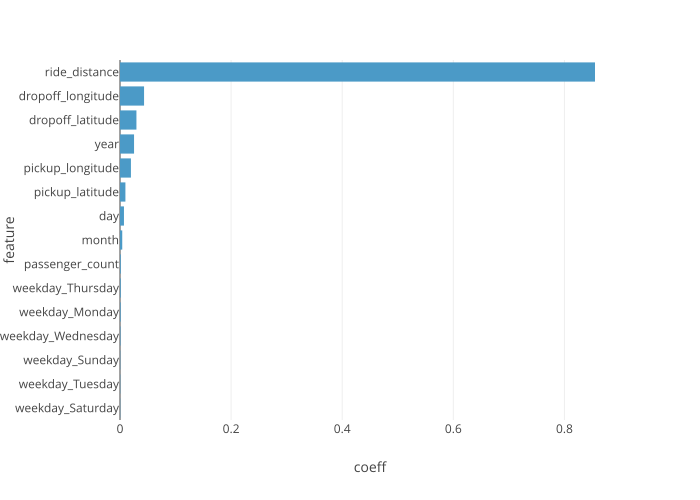

In [93]:
fig1 = px.bar(new_pd.sort_values(ascending=True, by="coeff"), x="coeff", y="feature")
fig1.update_layout(showlegend = False, 
                  margin = {'l': 120} # to avoid cropping of column names
                 )
fig1.show()

14. Would the model be able to make good predictions if we hadn't included the ride distance by hand? Train a new Random Forest model (with grid search) by dropping the `ride_distance` column from the features, and conclude.

In [94]:
df_2 = df.drop("ride_distance", axis=1)
df_2.head()

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,day,weekday
0,13.0,-73.971664,40.797035,-73.958939,40.777649,1,2015,5,7,Thursday
1,5.5,-73.991635,40.749855,-73.988250,40.741341,2,2014,7,9,Wednesday
2,8.5,-73.982352,40.777042,-73.995912,40.759757,1,2013,11,11,Monday
3,19.0,-73.991455,40.751700,-73.936357,40.812327,1,2014,5,22,Thursday
4,7.7,-73.974749,40.756255,-73.952276,40.778332,1,2011,6,21,Tuesday


In [95]:
Y = df_2.loc[:, target_variable]
X = df_2.drop(target_variable, axis=1)

numeric_features = []
categorical_features = []
for i, t in X.dtypes.items():
    if ("float" in str(t)) or ("int" in str(t)):
        numeric_features.append(i)
    else:
        categorical_features.append(i)

print("Found numeric features ", numeric_features)
print("Found categorical features ", categorical_features)

Found numeric features  ['pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'passenger_count', 'year', 'month', 'day']
Found categorical features  ['weekday']


In [96]:
print("Dividing into train and test sets...")
# WARNING : don't forget stratify=Y for classification problems
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=0)
print("...Done.")
print()

Dividing into train and test sets...
...Done.



In [97]:
# Create a pipeline for numeric features
numeric_transformer = StandardScaler()

In [98]:
# Create a pipeline for categorical features
categorical_transformer = OneHotEncoder(drop="first")

In [99]:
# Use Column Transformer to make a preprocessor object that describes all the treatments to be done
preprocessor = ColumnTransformer(
    [
        ('num', numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [100]:
# Prerprocessings on train set
print("Preprocessings on train set...")
print(X_train.head())
X_train = preprocessor.fit_transform(X_train)
print("...Done.")
print(X_train[:5])
print("")

print("Preprocessings on test set...")
print(X_test.head())
X_test = preprocessor.transform(X_test)
print("...Done.")
print(X_test[:5])
print("")

Preprocessings on train set...
       pickup_longitude  pickup_latitude  dropoff_longitude  dropoff_latitude  \
8152         -73.966328        40.757692         -73.958325         40.768067   
1380         -73.988100        40.764807         -74.001052         40.746947   
14079        -74.003445        40.743692         -74.005457         40.738923   
7725         -73.961230        40.760852         -73.957473         40.722320   
14918        -73.966034        40.767998         -73.954902         40.783116   

       passenger_count  year  month  day    weekday  
8152                 1  2012      2   16   Thursday  
1380                 1  2013     10   23  Wednesday  
14079                1  2009      5   22     Friday  
7725                 1  2013     11   10     Sunday  
14918                1  2014      4    2  Wednesday  
...Done.
[[-0.14344502  0.14080045 -0.14430518  0.12085588 -0.52674365  0.14178757
  -1.22949054  0.03136581  0.          0.          0.          1.
   0.    

In [101]:
# perform grid search
print("Grid search...")
regressor_forest_params = RandomForestRegressor()

# Grid of values to be tested
params = {
    'max_depth': [10, 12, 14],
    'min_samples_split': [4, 8],
    'n_estimators': [60, 80, 100]
}

gridsearch = GridSearchCV(
    regressor_forest_params, param_grid=params, cv=3, verbose=2
)
gridsearch.fit(X_train, Y_train)
print("...Done")
print(f"Best hyperparameters : {gridsearch.best_params_}")
print(f"Best validation accuracy : {gridsearch.best_score_}")

Grid search...
Fitting 3 folds for each of 18 candidates, totalling 54 fits
[CV] END .max_depth=10, min_samples_split=4, n_estimators=60; total time=   1.8s
[CV] END .max_depth=10, min_samples_split=4, n_estimators=60; total time=   1.7s
[CV] END .max_depth=10, min_samples_split=4, n_estimators=60; total time=   1.8s
[CV] END .max_depth=10, min_samples_split=4, n_estimators=80; total time=   2.4s
[CV] END .max_depth=10, min_samples_split=4, n_estimators=80; total time=   2.4s
[CV] END .max_depth=10, min_samples_split=4, n_estimators=80; total time=   2.4s
[CV] END max_depth=10, min_samples_split=4, n_estimators=100; total time=   3.0s
[CV] END max_depth=10, min_samples_split=4, n_estimators=100; total time=   3.0s
[CV] END max_depth=10, min_samples_split=4, n_estimators=100; total time=   3.0s
[CV] END .max_depth=10, min_samples_split=8, n_estimators=60; total time=   1.8s
[CV] END .max_depth=10, min_samples_split=8, n_estimators=60; total time=   1.7s
[CV] END .max_depth=10, min_sampl

In [102]:
print(f"R2 score on training set : {gridsearch.score(X_train, Y_train)}")
print(f"R2 score on test set : {gridsearch.score(X_test, Y_test)}")
print('Predictions on training set...')
y_train_pred = gridsearch.predict(X_train)
print("...Done.")
print(y_train_pred[:5])
print()
print("Predictions on test set...")
y_test_pred = gridsearch.predict(X_test)
print(y_test_pred[:5])
print()
print("Mean Absolute Error on training set :", mean_absolute_error(y_true=Y_train, y_pred=y_train_pred))
print("Mean Fare on training set : ", Y_train.mean())
print()
print("Mean Absolute Error on test set :", mean_absolute_error(y_true=Y_test, y_pred=y_test_pred))
print("Mean Fare on test set : ", Y_test.mean())
print("Standard deviation on test set : ", Y_test.std())

R2 score on training set : 0.8501076625302242
R2 score on test set : 0.7111055940504654
Predictions on training set...
...Done.
[ 7.51357631  8.6369815   7.47400991 26.75058476  8.94874893]

Predictions on test set...
[13.76742512  8.64574915  8.01305023  7.4954663   8.65596795]

Mean Absolute Error on training set : 2.4274398025381343
Mean Fare on training set :  11.330150643830478

Mean Absolute Error on test set : 2.859973205866101
Mean Fare on test set :  11.481740000000002
Standard deviation on test set :  9.631479542206511


Without the ride distance explicitely included as an input feature in the model, the performances are still way better than the baseline! This happens thanks to the non-linearity of Random Forest. The model is able to extract from the GPS coordinates some information that is somehow correlated with the ride distance. However, the predictions are not as good as the ones obtained before, which shows the importance of feature engineering, as Random Forest is limited by the type of functions it can approximate.